In [1]:

### DATA SETTINGS ###

TRAIN_INPUT = "gp"      # Use "gp" to train with GP-generated labels, or "theo" to train with theoretical labels

N_GP = 5                # Number of GP training points. Should be 5, 10 or 50.
                        # This must match the filename, e.g., X_ngp_5_-50_dbm.mat

N_AI = 1250000          # Number of samples used by the Python script.

N_SAMPLES_GP = N_GP     # Number of GP samples. Set equal to N_GP.

P_T = 0               # Transmit power in dBm.
                        # Valid values should match the available files, e.g., -50:10:0.
                        # Example: P_T = -50 corresponds to files ending with "_-50_dbm.mat".

# The following filenames must exactly match the saved .mat files in the data folder.
# For example, if N_GP = 5 and P_T = -50, the filenames become:
# X_FILE     = "X_ngp_5_-50_dbm.mat"
# YGP_FILE   = "Y_gp_ngp_5_-50_dbm.mat"
# YTHEO_FILE = "Y_theoretical_ngp_5_-50_dbm.mat"

X_FILE = f"X_ngp_{N_GP}_{P_T}_dbm.mat"
YGP_FILE = f"Y_gp_ngp_{N_GP}_{P_T}_dbm.mat"
YTHEO_FILE = f"Y_theoretical_ngp_{N_GP}_{P_T}_dbm.mat"

EPOCHS = 120

import os
import random
import glob
import shutil
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import savemat

In [2]:
def load_mat_array(filepath, var_name=None, dtype=np.float32):
    """
    Load one array from a MATLAB .mat file.
    Works with both old MAT files and v7.3 HDF5-style MAT files.
    """
    try:
        data = scipy.io.loadmat(filepath)
        keys = [k for k in data.keys() if not k.startswith("__")]
        if len(keys) == 0:
            raise ValueError(f"No variables found in {filepath}")

        key = var_name if (var_name is not None and var_name in data) else keys[0]
        arr = data[key]

    except NotImplementedError:
        # likely MATLAB v7.3
        with h5py.File(filepath, "r") as f:
            keys = list(f.keys())
            if len(keys) == 0:
                raise ValueError(f"No datasets found in {filepath}")

            key = var_name if (var_name is not None and var_name in f) else keys[0]
            arr = f[key][...]

    return np.array(arr, dtype=dtype)


def ensure_samples_by_features(A, expected_features):
    """
    Convert:
      (features, N) -> (N, features)
    or keep:
      (N, features) -> (N, features)
    """
    if A.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {A.shape}")

    if A.shape[1] == expected_features:
        return A
    elif A.shape[0] == expected_features:
        return A.T
    else:
        raise ValueError(
            f"Cannot orient array with expected_features={expected_features}. "
            f"Got shape {A.shape}"
        )



def seed_everything(seed: int = 42, deterministic: bool = True):
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make CPU behavior more repeatable (optional but helpful)
    torch.set_num_threads(1)

    if deterministic:
        # CUDA determinism settings (only matter if you use GPU)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

        # Avoid TF32 differences across GPUs
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

        # Force deterministic algorithms (may throw if an op has no deterministic version)
        torch.use_deterministic_algorithms(True)

        # For PyTorch 2.x attention kernels, try to avoid non-deterministic fast paths
        try:
            torch.backends.cuda.enable_flash_sdp(False)
            torch.backends.cuda.enable_mem_efficient_sdp(False)
            torch.backends.cuda.enable_math_sdp(True)
        except Exception:
            pass



def wrap_to_pi(x): # Wrap to (-pi, pi].
    return np.mod(x + np.pi, 2*np.pi) - np.pi

def make_ap_positions_3d(): # Generate 3D AP positions with fixed height h_ap=4.0
    ap_locs_xy = np.array([[5.00, 5.00],[4.5, 3.0],[2.0, 3.73],[6.5, 3.0],[3.0, 6.0],
        [5.0, 7.0],[8.0, 6.0],[8.0, 4.0],[7.0, 7.0],[1.2, 3.0],[2.3, 1.73],[7.5, 1.0],
        [8.0, 2.15],[1.3, 7.0],[0.5, 8.9],[8.0, 9.2],[7.0, 7.9],
    ], dtype=np.float64) # (17,2)

    h_ap = 4.0
    z = np.full((ap_locs_xy.shape[0], 1), h_ap, dtype=np.float64) # (17,1)
    ap_xyz = np.hstack([ap_locs_xy, z])  # (17,3)
    return ap_xyz, h_ap

def tokenize_measurements_arrays(
    phases,
    ue_xyz,
    print_preview=True,
):
    ap_xyz, _ = make_ap_positions_3d()
    M = ap_xyz.shape[0]

    phases = np.asarray(phases)
    N = phases.shape[0]

    if phases.shape[1] == M:
        phi = phases.astype(np.float64, copy=False)
    elif phases.shape[1] == (M - 1):
        phi = np.zeros((N, M), dtype=np.float64)
        phi[:, 1:] = phases.astype(np.float64, copy=False)
    else:
        raise ValueError(f"phases must have shape (N,{M}) or (N,{M-1}), got {phases.shape}")

    y = np.asarray(ue_xyz, dtype=np.float64)
    if y.shape != (N, 3):
        raise ValueError(f"ue_xyz must have shape (N,3). Got {y.shape}")

    phi_signed = wrap_to_pi(phi)

    sin_phi = np.sin(phi_signed)
    cos_phi = np.cos(phi_signed)

    X_tokens = np.concatenate([
        sin_phi[:, :, None],
        cos_phi[:, :, None]
    ], axis=2)

    feature_names = ["sin_phi", "cos_phi"]
    ap_ids = np.arange(M, dtype=np.int32)

    if print_preview:
        print("Tokenized from arrays.")
        print("X shape:", X_tokens.shape)
        print("y shape:", y.shape)
        print("First sample, AP0 token:", X_tokens[0, 0, :])
        print("First sample, AP1 token:", X_tokens[0, 1, :])

    return X_tokens.astype(np.float32), y.astype(np.float32), ap_ids, feature_names

def train_val_test_split(N, train_ratio=0.8, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)
    n_train = int(train_ratio * N)
    n_val = int(val_ratio * N)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return train_idx, val_idx, test_idx

class StandardScalerNP:
    """Simple mean/std scaler for numpy arrays."""
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, x, eps=1e-12):
        self.mean_ = x.mean(axis=0, keepdims=True)
        self.std_ = x.std(axis=0, keepdims=True) + eps
        return self

    def transform(self, x):
        return (x - self.mean_) / self.std_

    def inverse_transform(self, x):
        return x * self.std_ + self.mean_


class TokenDataset(Dataset):
    def __init__(self, X, y):
        # store as float32 for speed on GPU
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [3]:

seed_everything(42, deterministic=True)
# ---- load UE positions ----
X_all = load_mat_array(X_FILE, var_name="X", dtype=np.float32)
X_all = ensure_samples_by_features(X_all, expected_features=3)   # -> (N,3)

# ---- choose which phase matrix to use for TRAIN/VAL/TEST ----
if TRAIN_INPUT == "gp":
    phases_all = load_mat_array(YGP_FILE, var_name="Y_gp", dtype=np.float32)
else:
    phases_all = load_mat_array(YTHEO_FILE, var_name="Y_theoretical", dtype=np.float32)

phases_all = ensure_samples_by_features(phases_all, expected_features=17)   # -> (N,17)

print("Loaded X_all:", X_all.shape)
print("Loaded phases_all:", phases_all.shape)



X_tokens_all, y_all, ap_ids_np, feature_names = tokenize_measurements_arrays(
    phases=phases_all,
    ue_xyz=X_all,
    print_preview=True
)

print("All tokens:", X_tokens_all.shape)
print("All labels:", y_all.shape)
print("Features:", len(feature_names), feature_names)




# ===== split full dataset =====
X_np = X_tokens_all
y_np = y_all

N = X_np.shape[0]
train_idx, val_idx, test_idx = train_val_test_split(
    N,
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42
)

X_train, y_train = X_np[train_idx], y_np[train_idx]
X_val,   y_val   = X_np[val_idx],   y_np[val_idx]
X_test,  y_test  = X_np[test_idx],  y_np[test_idx]

# Keep the raw phase measurements (N_test x 17) for the test split.
# We index phases_all with test_idx here — right after the split — so this
# array is guaranteed to be row-aligned with X_test / y_test and later with
# pred_m / true_m.  Shape: (N_test, 17), units: radians.
phases_test = phases_all[test_idx]   # (N_test, 17)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Test phases:", phases_test.shape)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ---- Feature scaling ----
scale_X = False
x_scaler = StandardScalerNP() if scale_X else None

if scale_X:
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    x_scaler.fit(X_train_flat)

    def scale_tokens(X):
        Xf = X.reshape(-1, X.shape[-1])
        Xf = x_scaler.transform(Xf)
        return Xf.reshape(X.shape)

    X_train = scale_tokens(X_train)
    X_val   = scale_tokens(X_val)
    X_test  = scale_tokens(X_test)

# ---- Target scaling ----
y_scaler = StandardScalerNP().fit(y_train)
y_train_s = y_scaler.transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

train_ds = TokenDataset(X_train, y_train_s)
val_ds   = TokenDataset(X_val,   y_val_s)
test_ds  = TokenDataset(X_test,  y_test_s)

batch_size = 500
train_seed = 42

# seed_worker ensures each DataLoader worker process gets a
# deterministic RNG state derived from the generator seed, preventing
# non-deterministic shuffling/augmentation across workers.
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(train_seed)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    generator=g,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

print("Train/Val/Test sizes:", len(train_ds), len(val_ds), len(test_ds))

Loaded X_all: (1250000, 3)
Loaded phases_all: (1250000, 17)
Tokenized from arrays.
X shape: (1250000, 17, 2)
y shape: (1250000, 3)
First sample, AP0 token: [0.45835859 0.88876735]
First sample, AP1 token: [ 0.59511454 -0.80364089]
All tokens: (1250000, 17, 2)
All labels: (1250000, 3)
Features: 2 ['sin_phi', 'cos_phi']
Train: (1000000, 17, 2) (1000000, 3)
Val:   (125000, 17, 2) (125000, 3)
Test:  (125000, 17, 2) (125000, 3)
Test phases: (125000, 17)
Device: cuda
Train/Val/Test sizes: 1000000 125000 125000


In [4]:
import torch
import torch.nn as nn


class TransformerEncoderBlock(nn.Module):
    """
    Pre-Norm Transformer encoder block.
    Shapes:
      x: (B, S, D)
    """
    def __init__(self, d_model, nhead, dim_ff, dropout):
        super().__init__()

        self.mha = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)

        # 2-layer FFN with GELU
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
            nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.mha(
            x_norm, x_norm, x_norm,
            need_weights=False,
        )
        x = x + self.drop1(attn_out)

        x_norm = self.norm2(x)
        x = x + self.ff(x_norm)
        return x


class UETransformerRegressor(nn.Module):
    def __init__(
        self,
        num_aps=17,
        in_features=18,
        d_model=256,
        nhead=4,
        num_layers=3,
        dim_ff=1024,
        dropout=0.01,
        two_heads=False,
    ):
        super().__init__()
        self.num_aps = num_aps
        self.in_features = in_features
        self.d_model = d_model
        self.two_heads = two_heads

        # Project input features (F) -> model dimension (D)
        self.in_proj = nn.Linear(in_features, d_model)

        # AP-ID embedding (no CLS needed for mean-pooling, but keep for compatibility)
        self.ap_embed = nn.Embedding(num_aps, d_model)

        self.drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])

        # Final LayerNorm after all blocks (standard for Pre-Norm)
        self.final_norm = nn.LayerNorm(d_model)

        if two_heads:
            self.head_xy = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Linear(d_model, 2)
            )
            self.head_z = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Linear(d_model, 1)
            )
        else:
            self.head = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, 128),
                nn.GELU(),
                nn.Linear(128, 3)
            )

    def forward(self, x):
        """
        x: (B, M, F) where M=num_aps, F=number of features
        """
        B, M, F = x.shape

        # Project features to D
        t = self.in_proj(x)  # (B, M, D)

        # Add AP-ID embeddings: [0, 1, 2, ..., M-1]
        ap_ids = torch.arange(M, device=x.device).unsqueeze(0).expand(B, -1)  # (B, M)
        t = t + self.ap_embed(ap_ids)

        t = self.drop(t)

        for layer in self.layers:
            t = layer(t)

        # Final norm (needed for Pre-Norm architecture)
        t = self.final_norm(t)

        pooled = t.mean(dim=1)  # (B, D)

        if self.two_heads:
            xy = self.head_xy(pooled)
            z  = self.head_z(pooled)
            out = torch.cat([xy, z], dim=1)  # (B,3)
        else:
            out = self.head(pooled)

        return out


In [5]:
from tqdm import tqdm
import time

def make_scheduler(optimizer, scheduler_name, num_epochs, steps_per_epoch, warmup_ratio=0.05):
    scheduler_name = scheduler_name.lower()
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = int(warmup_ratio * total_steps)

    if scheduler_name == "none":
        return None

    if scheduler_name == "onecycle":
        max_lr = optimizer.param_groups[0]["lr"]
        return torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=max_lr,
            total_steps=total_steps,
            pct_start=warmup_ratio,
            anneal_strategy="cos",
            cycle_momentum=False
        )

    if scheduler_name == "cosine_warmup":
        def lr_lambda(step):
            if step < warmup_steps:
                return (step + 1) / max(1, warmup_steps)
            progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
            return 0.5 * (1.0 + np.cos(np.pi * progress))
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    raise ValueError(f"Unknown scheduler_name='{scheduler_name}'")


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        loss = criterion(pred, yb)
        losses.append(loss.item())
    return float(np.mean(losses))


def train_model(
    X_shape,  # (N, M, F)
    train_loader,
    val_loader,
    test_loader=None,
    eval_test_every=1,
    num_epochs=30,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_ff=256,
    dropout=0.1,
    two_heads=False,
    lr=3e-4,
    weight_decay=1e-2,
    scheduler_name="cosine_warmup",
    warmup_ratio=0.05,
    grad_clip=1.0,
):
    _, M, F = X_shape

    train_losses, val_losses, test_losses = [], [], []
    lrs = []

    global_step = 0

    model = UETransformerRegressor(
        num_aps=M,
        in_features=F,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_ff=dim_ff,
        dropout=dropout,
        two_heads=two_heads
    ).to(device)


    criterion = nn.L1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, scheduler_name, num_epochs, steps_per_epoch, warmup_ratio)

    train_losses, val_losses = [], []
    global_step = 0


    t0_all = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        t0 = time.perf_counter()
        model.train()
        epoch_losses = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)

        for Xb, yb in pbar:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()

            pred = model(Xb)
            loss = criterion(pred, yb)

            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            epoch_losses.append(loss.item())
            global_step += 1

            cur_lr = optimizer.param_groups[0]["lr"]
            lrs.append(cur_lr)
            pbar.set_postfix(
                loss=f"{loss.item():.3e}",
                avg=f"{np.mean(epoch_losses):.3e}",
                lr=f"{cur_lr:.2e}"
            )

        tr = float(np.mean(epoch_losses))
        va = evaluate(model, val_loader, criterion)

        te = None
        if (test_loader is not None) and (eval_test_every is not None) and (eval_test_every > 0) and (epoch % eval_test_every == 0):
            te = evaluate(model, test_loader, criterion)

        train_losses.append(tr)
        val_losses.append(va)
        test_losses.append(te if te is not None else np.nan)

        epoch_time = time.perf_counter() - t0
        total_time = time.perf_counter() - t0_all
        cur_lr = optimizer.param_groups[0]["lr"]

        msg = (
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"time {epoch_time:6.2f}s | total {total_time/60:6.2f} min | "
            f"lr {cur_lr:.2e} | train {tr:.6e} | val {va:.6e}"
        )
        if te is not None:
            msg += f" | test {te:.6e}"
        print(msg)

    return model, train_losses, val_losses, test_losses, lrs

In [6]:
seed_everything(train_seed, deterministic=True)

g.manual_seed(train_seed)

t0 = time.perf_counter()

model, tr_losses, va_losses, te_losses, lrs = train_model(
    X_shape=X_train.shape,         # (N, M, F)
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    eval_test_every=20,
    num_epochs=EPOCHS,

    d_model=256,
    nhead=4,
    num_layers=3,
    dim_ff=1024,
    dropout=0.01,
    two_heads=False,

    lr=10e-4,
    weight_decay=0.5e-6,
    scheduler_name="onecycle",  # "none", "onecycle", "cosine_warmup"
    warmup_ratio=0.05,
    grad_clip=1.0
)


t1 = time.perf_counter()
print(f"Total training runtime: {t1 - t0:.2f} seconds ({(t1 - t0)/60:.2f} minutes)")

Epoch 001/1 | time 127.70s | total   2.13 min | lr 4.68e-09 | train 8.251312e-01 | val 7.985262e-01
Total training runtime: 128.00 seconds (2.13 minutes)


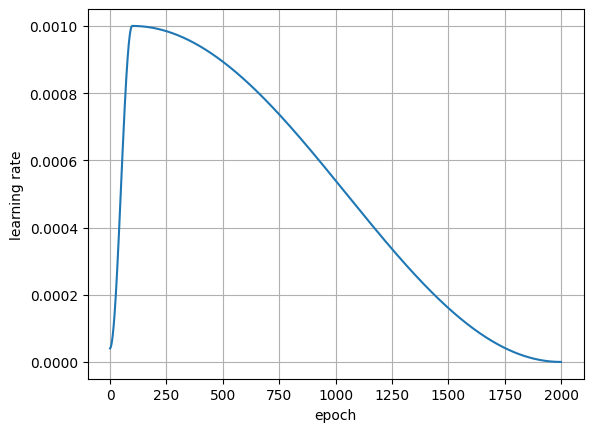

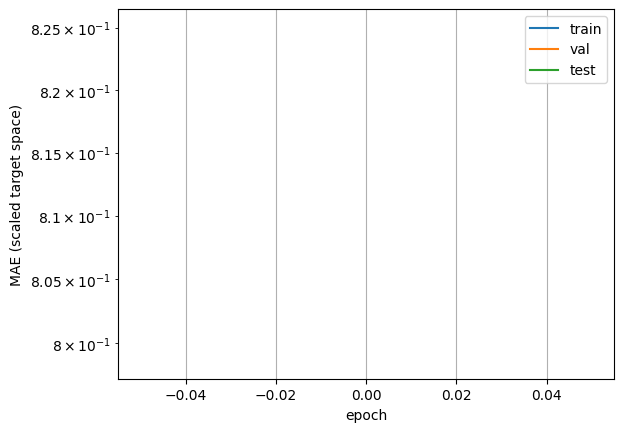

Saved loss history: artifacts/losses_gp_5_samples_0dbm.mat  (1 epochs)
RMSE x,y,z (m): [2.5077803  2.4816022  0.83912706]
RMSE 3D (m): 3.6265335
RMSE 3D (mm): 3626.5334
Mean 3D distance error (m): 3.332494
Mean 3D distance error (mm): 3332.4941
Saved: artifacts/results_gp_5_samples_0dbm.mat
  results matrix : (125000, 23)  [phases(17) | true_xyz(3) | pred_xyz(3)]
  phases         : (125000, 17)
  true_m         : (125000, 3)
  pred_m         : (125000, 3)


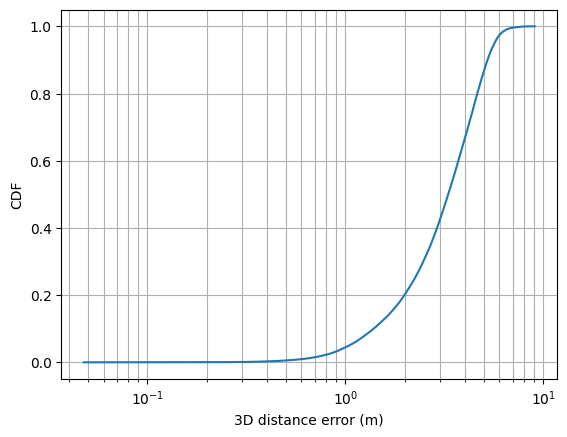

In [7]:
# ===== Plot learning rate vs epochs =====
plt.figure()
plt.plot(lrs)
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.grid(True)
plt.show()

# ===== plot train/val loss =====
plt.figure()
plt.plot(tr_losses, label="train")
plt.plot(va_losses, label="val")
plt.plot(te_losses, label="test")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MAE (scaled target space)")
plt.legend()
plt.grid(True)
plt.show()

out_dir = Path("artifacts")
out_dir.mkdir(parents=True, exist_ok=True)


if TRAIN_INPUT == 'gp':
    loss_tag = f"losses_{TRAIN_INPUT}_{N_SAMPLES_GP}_samples_{P_T}dbm"
if TRAIN_INPUT == 'theo':
    loss_tag = f"losses_{TRAIN_INPUT}_{P_T}dbm"

loss_fname = out_dir / f"{loss_tag}.mat"

te_losses_clean = [v if v is not None else np.nan for v in te_losses]

savemat(loss_fname, {
    "train_loss": np.array(tr_losses, dtype=np.float64).reshape(-1, 1),
    "val_loss":   np.array(va_losses, dtype=np.float64).reshape(-1, 1),
    "test_loss":  np.array(te_losses_clean, dtype=np.float64).reshape(-1, 1),
    "epochs":     np.arange(1, len(tr_losses) + 1, dtype=np.float64).reshape(-1, 1),
    "lrs":        np.array(lrs, dtype=np.float64).reshape(-1, 1),
})

print(f"Saved loss history: {loss_fname}  ({len(tr_losses)} epochs)")

# ===== test metrics in real units =====
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds = []
    trues = []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        pred = model(Xb).cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

pred_s, true_s = predict_all(model, test_loader)

# invert scaling back to meters
pred_m = y_scaler.inverse_transform(pred_s)
true_m = y_scaler.inverse_transform(true_s)

err = pred_m - true_m
rmse_xyz = np.sqrt(np.mean(err**2, axis=0))
rmse_3d = np.sqrt(np.mean(np.sum(err**2, axis=1)))
mean_3d_dist = np.mean(np.linalg.norm(err, axis=1))


print("RMSE x,y,z (m):", rmse_xyz)
print("RMSE 3D (m):", rmse_3d)
print("RMSE 3D (mm):", rmse_3d * 1000.0)
print("Mean 3D distance error (m):", mean_3d_dist)
print("Mean 3D distance error (mm):", mean_3d_dist * 1000.0)

# ===== Save results .mat file =====
# The goal: one .mat file per run that contains everything needed to
# refine the estimated positions in MATLAB using gradient descent.
#
# Row layout of the combined matrix (results):
#   cols  1-17  : raw phase measurements phi_1 … phi_17  [radians]
#   cols 18-20  : true UE position  [x_true, y_true, z_true]  [metres]
#   cols 21-23  : estimated UE position [x_pred, y_pred, z_pred]  [metres]
#


# Build the filename tag based on training-input type
if TRAIN_INPUT == 'gp':
    tag = f"results_{TRAIN_INPUT}_{N_SAMPLES_GP}_samples_{P_T}dbm"
if TRAIN_INPUT == 'theo':
    tag = f"results_{TRAIN_INPUT}_{P_T}dbm"



fname = out_dir / f"{tag}.mat"

# --- sanity-check: all arrays must have the same number of rows ---
assert phases_test.shape[0] == true_m.shape[0] == pred_m.shape[0], (
    f"Row count mismatch: phases={phases_test.shape[0]}, "
    f"true_m={true_m.shape[0]}, pred_m={pred_m.shape[0]}"
)

# Combined matrix: each row = [phases(17) | true_xyz(3) | pred_xyz(3)]
# Shape: (N_test, 23)


results_combined = np.hstack([
    phases_test.astype(np.float64),   # (N_test, 17) — raw phase, radians
    true_m.astype(np.float64),        # (N_test,  3) — true position, metres
    pred_m.astype(np.float64),        # (N_test,  3) — estimated position, metres
])  # -> (N_test, 23)

savemat(fname, {
    # --- combined matrix (convenient for MATLAB loops) ---
    # rows = test samples, cols = [phi_1..phi_17, x_true,y_true,z_true, x_pred,y_pred,z_pred]
    "results": results_combined,

    # --- individual arrays (convenient for direct access by name) ---
    "phases":        phases_test.astype(np.float64),  # (N_test, 17)  raw phase [rad]
    "true_m":        true_m.astype(np.float64),       # (N_test,  3)  true xyz  [m]
    "pred_m":        pred_m.astype(np.float64),       # (N_test,  3)  estimated xyz [m]
    "err":           err.astype(np.float64),           # (N_test,  3)  pred - true [m]

    # --- scalar summary metrics ---
    "rmse_xyz":      rmse_xyz,       # (3,) per-axis RMSE [m]
    "rmse_3d":       rmse_3d,        # scalar 3-D RMSE [m]
    "mean_3d_dist":  mean_3d_dist,   # scalar mean 3-D distance error [m]

    # --- metadata (useful when loading multiple files in MATLAB) ---
    "train_input":   TRAIN_INPUT,
    "n_gp":          float(N_GP),
    "p_t_dbm":       float(P_T),
})

print(f"Saved: {fname}")
print(f"  results matrix : {results_combined.shape}  "
      f"[phases(17) | true_xyz(3) | pred_xyz(3)]")
print(f"  phases         : {phases_test.shape}")
print(f"  true_m         : {true_m.shape}")
print(f"  pred_m         : {pred_m.shape}")

import numpy as np
import matplotlib.pyplot as plt

# 3D distance error per sample (meters)
d = np.linalg.norm(err, axis=1).astype(float)

# (optional) avoid log(0) issues if any perfect predictions exist
d = np.clip(d, np.finfo(float).tiny, None)

# empirical CDF
x = np.sort(d)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure()
plt.plot(x, y)
plt.xscale('log')
plt.xlabel('3D distance error (m)')
plt.ylabel('CDF')
plt.grid(True, which='both')
#plt.savefig("cdf_3d_error_logx.png", dpi=300, bbox_inches="tight")  # <--- save

plt.show()

In [8]:
# ===== Save artifacts (Transformer + scalers) =====
import os, pickle, torch

ART_DIR = "/content/artifacts"
os.makedirs(ART_DIR, exist_ok=True)

# --- 1) Build consistent filename stems for this run ---
# Use the same tag logic as the results/losses savemat blocks above so all
# output files for a given run share the same suffix and are easy to match.
if TRAIN_INPUT == 'gp':
    _stem = f"{TRAIN_INPUT}_{N_SAMPLES_GP}_samples_{P_T}dbm"
else:  # 'theo'
    _stem = f"{TRAIN_INPUT}_{P_T}dbm"

y_scaler_path = os.path.join(ART_DIR, f"y_scaler_{_stem}.pkl")
x_scaler_path = os.path.join(ART_DIR, f"x_scaler_{_stem}.pkl")
model_path    = os.path.join(ART_DIR, f"ue_transformer_ckpt_{_stem}.pt")
results_path  = str(out_dir / f"results_{_stem}.mat")
losses_path   = str(out_dir / f"losses_{_stem}.mat")

with open(y_scaler_path, "wb") as f:
    pickle.dump(y_scaler, f)


if "x_scaler" in globals() and (x_scaler is not None):
    with open(x_scaler_path, "wb") as f:
        pickle.dump(x_scaler, f)
else:
    x_scaler_path = None

# ---  Save model checkpoint (state_dict + kwargs to rebuild the SAME Transformer) ---
model_kwargs = dict(
    num_aps=X_train.shape[1],
    in_features=X_train.shape[2],
    d_model=256,
    nhead=4,
    num_layers=3,
    dim_ff=1024,
    dropout=0.01,
    two_heads=False,
)

ckpt = {
    "arch": "UETransformerRegressor",
    "model_state_dict": model.state_dict(),
    "model_kwargs": model_kwargs,
    "feature_names": feature_names,
    "tokenizer_cfg": {
        "fc_GHz": 0.8,
        "side_length_m": 10.0,
        "force_ap0_angles_and_proj_zero": False,
        "include_cls_token": False,
    },
}


torch.save(ckpt, model_path)

print("Saved:", model_path)
print("Saved:", y_scaler_path)
if x_scaler_path is not None:
    print("Saved:", x_scaler_path)


Saved: /content/artifacts/ue_transformer_ckpt_gp_5_samples_0dbm.pt
Saved: /content/artifacts/y_scaler_gp_5_samples_0dbm.pkl


In [9]:
from google.colab import files
import zipfile

# --- Zip all output files and download as a single archive ---
zip_name = f"results_{TRAIN_INPUT}_{N_GP}_{P_T}dBm.zip"
zip_path = os.path.join(ART_DIR, zip_name)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(model_path,   os.path.basename(model_path))
    zf.write(y_scaler_path, os.path.basename(y_scaler_path))
    zf.write(results_path,  os.path.basename(results_path))
    zf.write(losses_path,   os.path.basename(losses_path))

print(f"Downloading: {zip_name}")
files.download(zip_path)

Downloading: results_gp_5_0dBm.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>